In [1]:
import sys
import os

# 現在の作業ディレクトリを基にプロジェクトのルートディレクトリを設定
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)
print(project_root)

c:\Users\keisu\Desktop\研究元ファイル\abnormal\research_abnormal


In [42]:
#必要ライブラリのインストール
from src import data
from src import data
from src import model_basic
from src import store
from src import plot
from src.model import model_check_features


import warnings

# 全ての警告を無視
warnings.filterwarnings('ignore', category=UserWarning)

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # エラーのみ表示


In [3]:
#データの読み込み及び加工、コラムリストの取得
colums_list, data_ex, data_original = data.data_complete()

キャッシュファイルからデータを読み込みます


In [4]:
#データの確認
data_ex

,processor_unit_units_status_cpu_board_cpu_fan,processor_unit_units_status_cpu_board_cpu_bd_fan1,processor_unit_units_status_cpu_board_cpu_bd_fan2,processor_unit_units_status_cpu_board_cpu_bd_temp,processor_unit_units_status_cpu_board_cpu_core_temp,processor_unit_units_status_cpu_board_gpu_core_temp,processor_unit_units_status_cpu_board_cpu_core_vol,processor_unit_units_status_cpu_board_cpu_bd_vbat,processor_unit_units_status_cpu_board_cpu_bd_p3_3v,processor_unit_units_status_cpu_board_cpu_bd_p5v,processor_unit_units_status_cpu_board_cpu_bd_p12v,measurement_date
0,0.735761,0.562054,0.902923,0.740751,0.638899,0.633343,0.324796,0.393949,0.68001,0.00001,0.073539,2015-12-22 06:15:00
1,0.766849,0.649645,0.913514,0.777788,0.666677,0.666677,0.977218,0.181828,0.68001,0.00001,0.000010,2015-12-22 07:00:02
2,0.797937,0.562054,0.928518,0.814825,0.694454,0.700010,0.868956,0.181828,0.84001,0.00001,0.073539,2015-12-22 08:00:03
3,0.834207,0.562054,0.924988,0.814825,0.694454,0.700010,0.817674,0.181828,0.68001,0.00001,0.073539,2015-12-22 09:00:03
4,0.735761,0.474463,0.924988,0.777788,0.666677,0.633343,0.524227,0.393949,0.68001,0.80001,0.073539,2015-12-22 10:00:03
...,...,...,...,...,...,...,...,...,...,...,...,...
26420,0.378248,0.364974,0.688448,0.444454,0.361121,0.466677,0.868956,0.000010,0.68001,1.00001,1.000010,2019-02-04 19:00:02
26421,0.378248,0.364974,0.792596,0.444454,0.361121,0.500010,0.834768,0.000010,0.00001,1.00001,1.000010,2019-02-04 20:00:02
26422,0.378248,0.277382,0.765235,0.444454,0.333343,0.466677,0.735053,0.000010,0.68001,1.00001,1.000010,2019-02-04 21:00:02
26423,0.378248,0.364974,0.724635,0.444454,0.333343,0.466677,0.501435,0.000010,0.68001,1.00001,1.000010,2019-02-04 22:00:02


ここからモデルの作成に入る

In [5]:
#ハイパーパラメータの設定

#オートエンコーダの重みの初期化方法
initializer = "glorot_normal"


#モデルの最小化関数のパラメータ
delta = 0.5

#最大エポック数
max_epochs = 10

#ノード数
units = 11

#モデル決定の閾値（再構成誤差のパラメータ）
#この閾値を下回ることで十分な性能を持つモデルとする
error_threshold = 0.002

# EarlyStoppingの設定
early_stopping_params = {
    'monitor': 'loss',
    'patience': 1,
    'min_delta': 10e-1,
    'restore_best_weights': True,
    'verbose': 0,
    'mode': 'min'
}



In [55]:
#実験の実行及び結果の格納
errors_train, errors_predict, abnormal_values = model_check_features.result(data_ex, colums_list,  initializer, error_threshold, max_epochs, early_stopping_params, units )

1回目の期間のモデル
該当期間の確認
はじまり(train)2016/6/01 00:00:00
終わり(train)2018/6/01 00:00:00
はじまり(test)2018/6/01 00:00:00
終わり(test)2018/7/01 00:00:00
1回目の期間のモデル作成開始
1回目の期間のトレーニングデータ数:17161
実験：decrease
実験：decreaseの1回目の実験：ノード数はunit1_3:29,unit_210
seed値：40
モデルは収束しました。訓練は 2 エポックで停止しました。
modelの更新：final_loss:0.18886896967887878
実験：decreaseの2回目の実験：ノード数はunit1_3:29,unit_210
seed値：41
モデルは収束しました。訓練は 2 エポックで停止しました。
modelの更新：final_loss:0.1870947629213333
実験：decreaseの3回目の実験：ノード数はunit1_3:29,unit_210
seed値：42
モデルは収束しました。訓練は 2 エポックで停止しました。
実験：decreaseの4回目の実験：ノード数はunit1_3:29,unit_210
seed値：43
モデルは収束しました。訓練は 2 エポックで停止しました。
modelの更新：final_loss:0.18282996118068695
実験：skip_decrease
実験：skip_decreaseの1回目の実験：ノード数はunit1_3:12,unit_210
seed値：40
モデルは収束しました。訓練は 2 エポックで停止しました。
modelの更新：final_loss:0.2723914384841919
実験：skip_decreaseの2回目の実験：ノード数はunit1_3:12,unit_210
seed値：41
モデルは収束しました。訓練は 2 エポックで停止しました。
modelの更新：final_loss:0.26597410440444946
実験：skip_decreaseの3回目の実験：ノード数はunit1_3:12,unit_210
seed値：42
モデルは収束しました。訓練は 2 エポックで停止しました。
実験：

In [40]:
print(errors_train)

{0: {'decrease': processor_unit_units_status_cpu_board_cpu_fan          0.159828
processor_unit_units_status_cpu_board_cpu_bd_fan1      0.148867
processor_unit_units_status_cpu_board_cpu_bd_fan2      0.115331
processor_unit_units_status_cpu_board_cpu_bd_temp      0.110190
processor_unit_units_status_cpu_board_cpu_core_temp    0.085291
processor_unit_units_status_cpu_board_gpu_core_temp    0.104926
processor_unit_units_status_cpu_board_cpu_core_vol     0.186208
processor_unit_units_status_cpu_board_cpu_bd_vbat      0.368202
processor_unit_units_status_cpu_board_cpu_bd_p3_3v     0.185651
processor_unit_units_status_cpu_board_cpu_bd_p5v       0.311218
processor_unit_units_status_cpu_board_cpu_bd_p12v      0.377219
dtype: float64, 'skip_decrease': processor_unit_units_status_cpu_board_cpu_fan          0.159828
processor_unit_units_status_cpu_board_cpu_bd_fan1      0.148867
processor_unit_units_status_cpu_board_cpu_bd_fan2      0.115331
processor_unit_units_status_cpu_board_cpu_bd_temp     

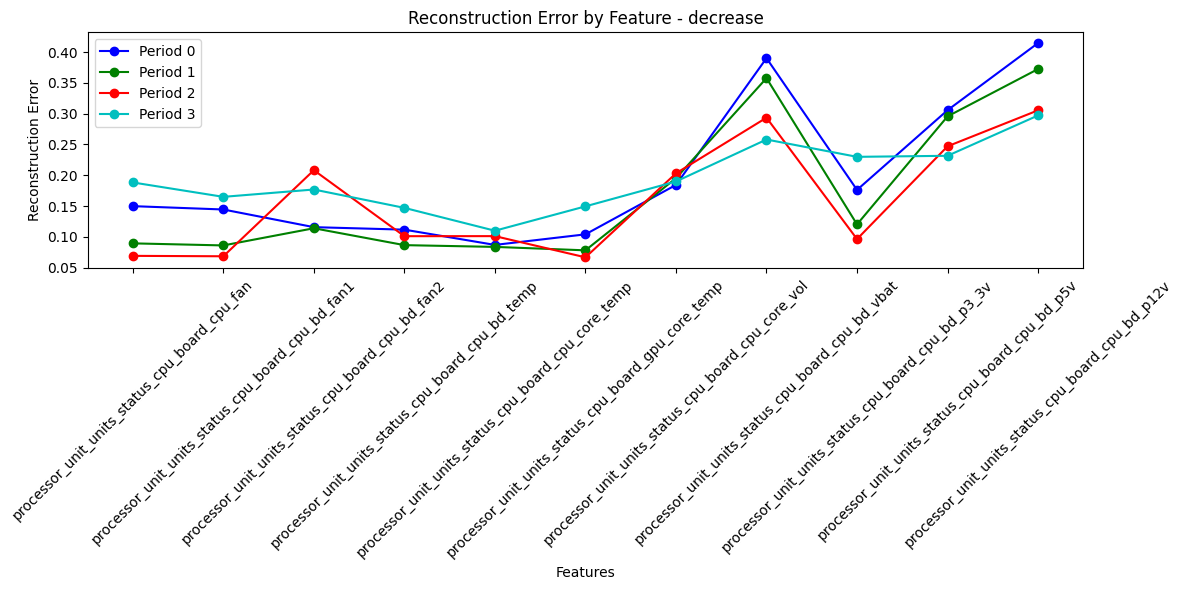

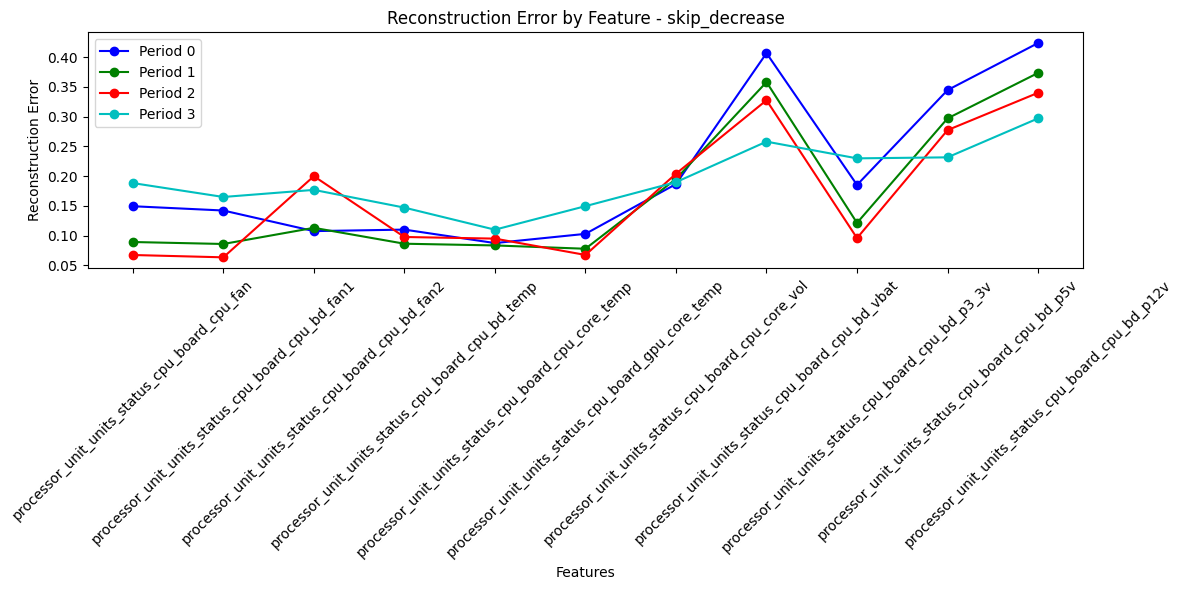

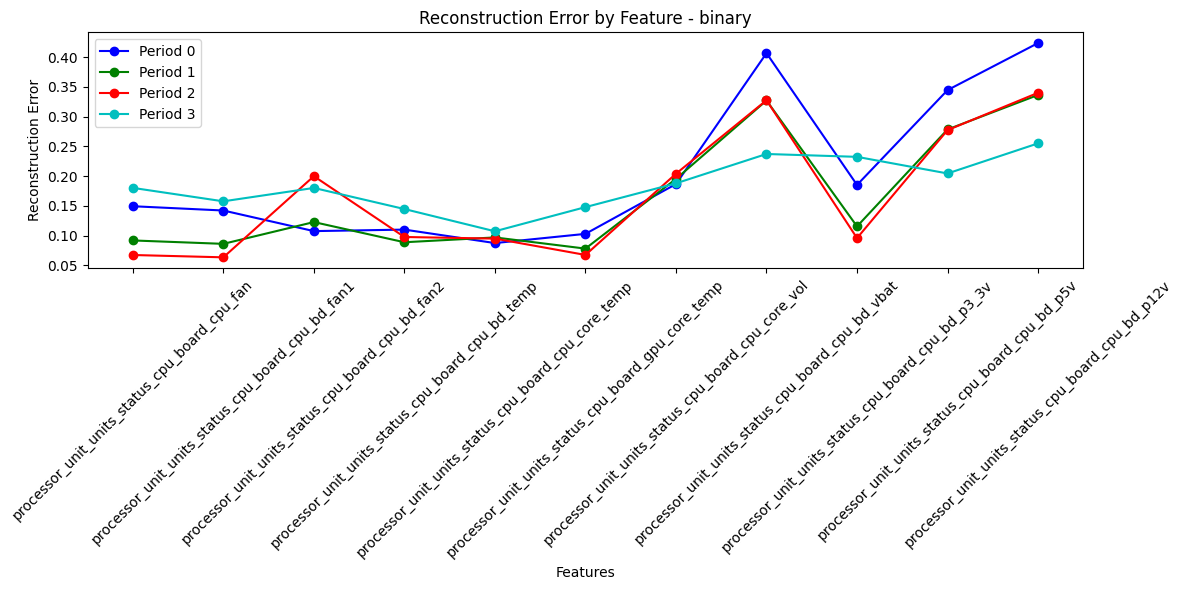

In [56]:
plot.plot_error_train(errors_train)

In [32]:
print(errors_train)

{0: {'decrease': processor_unit_units_status_cpu_board_cpu_fan          0.159828
processor_unit_units_status_cpu_board_cpu_bd_fan1      0.148867
processor_unit_units_status_cpu_board_cpu_bd_fan2      0.115331
processor_unit_units_status_cpu_board_cpu_bd_temp      0.110190
processor_unit_units_status_cpu_board_cpu_core_temp    0.085291
processor_unit_units_status_cpu_board_gpu_core_temp    0.104926
processor_unit_units_status_cpu_board_cpu_core_vol     0.186208
processor_unit_units_status_cpu_board_cpu_bd_vbat      0.368202
processor_unit_units_status_cpu_board_cpu_bd_p3_3v     0.185651
processor_unit_units_status_cpu_board_cpu_bd_p5v       0.311218
processor_unit_units_status_cpu_board_cpu_bd_p12v      0.377219
dtype: float64, 'skip_decrease': processor_unit_units_status_cpu_board_cpu_fan          0.159828
processor_unit_units_status_cpu_board_cpu_bd_fan1      0.148867
processor_unit_units_status_cpu_board_cpu_bd_fan2      0.115331
processor_unit_units_status_cpu_board_cpu_bd_temp     

In [33]:
print(errors_predict)


{0: {'decrease': processor_unit_units_status_cpu_board_cpu_fan          0.584634
processor_unit_units_status_cpu_board_cpu_bd_fan1      0.393079
processor_unit_units_status_cpu_board_cpu_bd_fan2      0.123484
processor_unit_units_status_cpu_board_cpu_bd_temp      0.549753
processor_unit_units_status_cpu_board_cpu_core_temp    0.424372
processor_unit_units_status_cpu_board_gpu_core_temp    0.541540
processor_unit_units_status_cpu_board_cpu_core_vol     0.000363
processor_unit_units_status_cpu_board_cpu_bd_vbat      0.354620
processor_unit_units_status_cpu_board_cpu_bd_p3_3v     0.635429
processor_unit_units_status_cpu_board_cpu_bd_p5v       0.297476
processor_unit_units_status_cpu_board_cpu_bd_p12v      0.375032
Name: 14134, dtype: float64, 'skip_decrease': processor_unit_units_status_cpu_board_cpu_fan          0.584634
processor_unit_units_status_cpu_board_cpu_bd_fan1      0.393079
processor_unit_units_status_cpu_board_cpu_bd_fan2      0.123484
processor_unit_units_status_cpu_board_cpu

In [34]:
print(abnormal_values)

{0: {'decrease': 0.35015573608885686, 'skip_decrease': 0.35015573608885686, 'binary': 0.35015573608885686}, 1: {'decrease': 0.31714034187705464, 'skip_decrease': 0.31714034187705464, 'binary': 0.31714034187705464}, 2: {'decrease': 0.3493505352997673, 'skip_decrease': 0.3493505352997673, 'binary': 0.3493505352997673}, 3: {'decrease': 0.3322981278786998, 'skip_decrease': 0.3322981278786998, 'binary': 0.3322981278786998}}


In [79]:
#結果の保存
store.store(results_df,"model_1")
store.store(thresholds,"thresholds_1")
store.store(traindata_model_df, "traindata_model_df_1")

In [9]:
#結果の抜き出し
results_df = store.read("model_1")
thresholds = store.read("thresholds_1")
traindata_model_df = store.read("traindata_model_df_1")

In [ ]:
#結果のプロット
plot.plot_all(results_df,thresholds, colums_list, data_original)

In [ ]:
plot.plot_predict(traindata_model_df, colums_list, data_ex)

In [38]:
#収束の確認
plot.plot_final_loss_vs_unit_sum(loss_values)

NameError: name 'loss_values' is not defined

In [54]:
#モジュールの再リロード
import importlib
import src
import src.model
import src.model_basic

importlib.reload(src.model)
importlib.reload(src.data)
importlib.reload(src.model_basic)
importlib.reload(src.model.model_check_features)
importlib.reload(src.plot)
from src import data
from src import model_basic
from src import store
from src import plot
from src.model import model_check_features

#必要ライブラリのインストール
from src import *
